# Part 11 — Specialized Topics

**Series:** *Time Series Analysis in Python — from Statistical Modeling to Machine Learning*

Parts 3–10 walked the main forecasting highway. Part 11 visits the important
**side roads** — problems that break the standard assumptions and need their own
tools: forecasts that must **add up** across a hierarchy, **structural breaks** and
**anomalies** hiding in a series, **intermittent** demand full of zeros, the
special pain of **long horizons**, and the new **foundation models** that forecast
a series they've never seen. Each is a compact, practical toolkit.

### What you will learn
1. **Hierarchical & grouped** forecasting with **reconciliation** (bottom-up, top-down, MinT)
2. **Change-point detection** — finding structural breaks (`ruptures`)
3. **Anomaly detection** — flagging outliers via decomposition residuals
4. **Intermittent/sparse demand** — Croston, ADIDA, TSB
5. **Long-horizon** forecasting challenges
6. **Foundation models** — TimeGPT, Chronos, Moirai, TimesFM (zero-/few-shot)

### Dataset
Still `monthly_price.csv`. New libraries: `hierarchicalforecast`, `statsforecast`,
`ruptures`.

## 0. Setup

In [1]:
import warnings, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.simplefilter("ignore")
for lg in ["statsforecast", "hierarchicalforecast"]:
    logging.getLogger(lg).setLevel(logging.ERROR)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "font.size": 11, "lines.linewidth": 1.6,
})
PALETTE = ["#2b6cb0", "#c05621", "#2f855a", "#6b46c1", "#b83280", "#718096"]

raw = pd.read_csv("monthly_price.csv")
dates = pd.to_datetime(raw["YEAR"].astype(str) + "-" + raw["MONTH"], format="%Y-%b")
df = raw.drop(columns=["ID", "YEAR", "MONTH", "TIME"]).copy()
df.index = dates; df.index.name = "date"; df = df.asfreq("MS")

def rmse(a, p): a,p=np.asarray(a),np.asarray(p); return np.sqrt(np.mean((a - p) ** 2))
print("ready — series:", list(df.columns))

ready — series: ['Urea_Price', 'MP_Price', 'TSP_Price', 'Maize_Price', 'Rice_Price', 'Wheat_Price', 'Food_Price_Index', 'Energy_Price_Index', 'VIX_Index']


## 1. Hierarchical & grouped forecasting

Forecasts often live in a **hierarchy**: product → category → total; store → region
→ country. A basic requirement is **coherence** — the forecasts must **add up**
(the sum of category forecasts should equal the total forecast). If you forecast
every level **independently**, they almost never do — and incoherent forecasts are
useless for planning.

**Reconciliation** fixes this. We build a small coherent hierarchy from the three
crop prices — a constructed **Total = Maize + Rice + Wheat** — and reconcile.

In [2]:
from hierarchicalforecast.utils import aggregate
crops = ["Maize_Price", "Rice_Price", "Wheat_Price"]
records = [{"Category": "Crops", "Item": c, "ds": ds, "y": float(v)}
          for c in crops for ds, v in df[c].items()]
bottom = pd.DataFrame(records)

# aggregate() builds the hierarchy: a 'Crops' total node + one node per crop
Y_df, S_df, tags = aggregate(bottom, spec=[["Category"], ["Category", "Item"]])
H = 12
train = Y_df[Y_df["ds"] < df.index[-H]]
test  = Y_df[Y_df["ds"] >= df.index[-H]]
print("hierarchy nodes:", Y_df["unique_id"].unique().tolist())
print("\nsumming matrix S (rows sum children into parents):")
print(S_df.to_string(index=False))

hierarchy nodes: ['Crops', 'Crops/Maize_Price', 'Crops/Rice_Price', 'Crops/Wheat_Price']

summing matrix S (rows sum children into parents):
        unique_id  Crops/Maize_Price  Crops/Rice_Price  Crops/Wheat_Price
            Crops                1.0               1.0                1.0
Crops/Maize_Price                1.0               0.0                0.0
 Crops/Rice_Price                0.0               1.0                0.0
Crops/Wheat_Price                0.0               0.0                1.0


We generate **base** forecasts independently for every node with `AutoARIMA`,
then measure how badly they violate coherence.

In [3]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
sf = StatsForecast(models=[AutoARIMA(season_length=12)], freq="MS", n_jobs=1)
base_fc = sf.forecast(df=train, h=H)

# incoherence of the base forecast: Total vs. sum of items
items = [u for u in Y_df["unique_id"].unique() if "/" in u]
def incoherence(fc, col):
    tot = fc[fc["unique_id"] == "Crops"][col].values
    itm = sum(fc[fc["unique_id"] == u][col].values for u in items)
    return np.mean(np.abs(tot - itm))
print(f"BASE forecast incoherence (|Total - sum items|, avg): "
      f"{incoherence(base_fc, 'AutoARIMA'):.2f}  <- forecasts DON'T add up")

BASE forecast incoherence (|Total - sum items|, avg): 10.72  <- forecasts DON'T add up


Now reconcile with three classic methods:

- **Bottom-up** — forecast the leaves, sum upward. Simple; ignores top-level signal.
- **Top-down** — forecast the total, split by historical proportions. Good top,
  weaker leaves.
- **MinT (minimum-trace)** — the optimal linear reconciliation: combines *all*
  levels, weighting by forecast-error covariance. Usually the most accurate.

In [4]:
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp, TopDown, MinTrace
hrec = HierarchicalReconciliation(reconcilers=[
    BottomUp(), TopDown(method="forecast_proportions"), MinTrace(method="ols")])
rec = hrec.reconcile(Y_hat_df=base_fc, tags=tags, S_df=S_df, Y_df=train)

methods = [c for c in rec.columns if c not in ("unique_id", "ds")]
rows = []
top_actual = test[test["unique_id"] == "Crops"]["y"].values
for m in methods:
    rows.append({"method": m.replace("AutoARIMA/", "").replace("AutoARIMA", "base (unreconciled)"),
                 "incoherence": round(incoherence(rec, m), 3),
                 "top-level RMSE": round(rmse(top_actual, rec[rec["unique_id"]=="Crops"][m].values), 1)})
pd.DataFrame(rows)

,method,incoherence,top-level RMSE
0,base (unreconciled),10.724,146.5
1,BottomUp,0.000,156.0
2,TopDown_method-forecast_proportions,0.000,146.5
3,MinTrace_method-ols,0.000,148.9


The base forecast is **incoherent** (a nonzero gap); **every reconciliation method
drives incoherence to exactly 0** — the forecasts now add up by construction. That
guarantee is the whole point: reconciled forecasts can be trusted across levels.
On accuracy, the methods differ little on this tiny 4-node hierarchy; **MinT's
accuracy edge grows with the size and depth** of the hierarchy (hundreds of
products across regions), where sharing information across levels really pays.

## 2. Change-point detection

A **change point** is a moment when the series' behaviour shifts regime — a new
mean, variance, or trend. Detecting them matters for segmentation, alerting, and
knowing when a model needs refitting. The `ruptures` library searches for the
break locations that best explain the series. We use **binary segmentation** and
ask for the 5 most significant breaks in the Food Price Index.

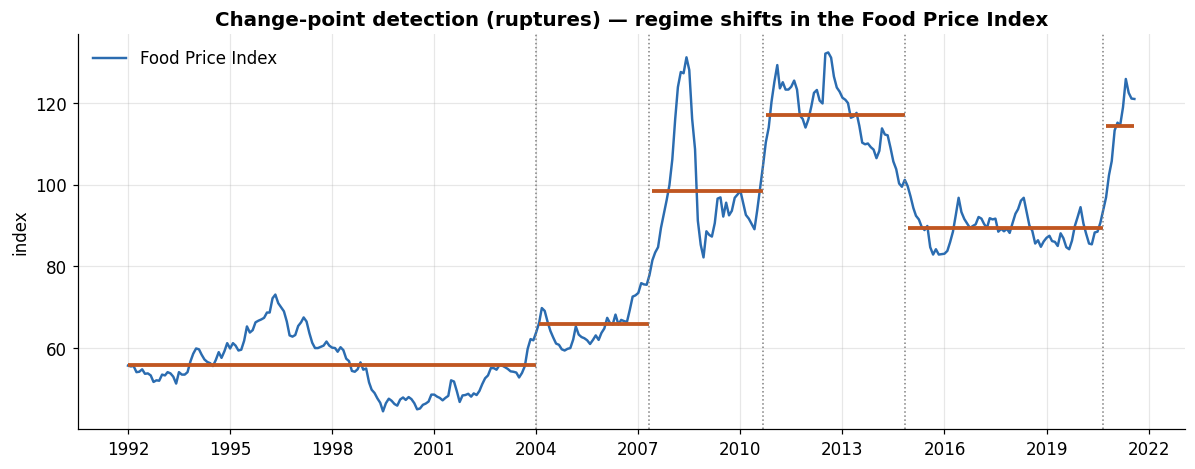

detected regime shifts: ['2004-01', '2007-05', '2010-09', '2014-11', '2020-09']


In [5]:
import ruptures as rpt
signal = df["Food_Price_Index"].values.astype(float)
bkps = rpt.Binseg(model="l2", min_size=6).fit(signal).predict(n_bkps=5)
break_dates = [df.index[b-1] for b in bkps if b < len(df)]

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(df.index, signal, color=PALETTE[0], label="Food Price Index")
prev = 0
for b in bkps:
    seg = signal[prev:b]
    ax.hlines(seg.mean(), df.index[prev], df.index[min(b-1, len(df)-1)],
              color=PALETTE[1], lw=2.5)
    prev = b
for bd in break_dates:
    ax.axvline(bd, color="grey", ls=":", lw=1)
ax.set_title("Change-point detection (ruptures) — regime shifts in the Food Price Index")
ax.set_ylabel("index"); ax.legend(frameon=False)
ax.xaxis.set_major_locator(mdates.YearLocator(3))
plt.tight_layout(); plt.show()
print("detected regime shifts:", [d.strftime("%Y-%m") for d in break_dates])

The orange segment-means show the regimes, and the detected breaks land on real
history: the **2007–08 food-price crisis**, the **2010** second spike, the
**2014** commodity downturn, and the **2020** COVID surge. The number of breaks is
a knob — a **penalty** (`Pelt(model="rbf").predict(pen=…)`) chooses it
automatically when you don't want to fix a count.

## 3. Anomaly detection

An **anomaly** is a single observation that doesn't fit the pattern — a spike, a
dropout, a data-entry error. A robust, model-light approach: **decompose** the
series (STL, Part 2), then flag points whose **residual** is many standard
deviations from zero. Because STL's trend and seasonal parts absorb the *expected*
structure, what's left in the residual is the *unexpected*.

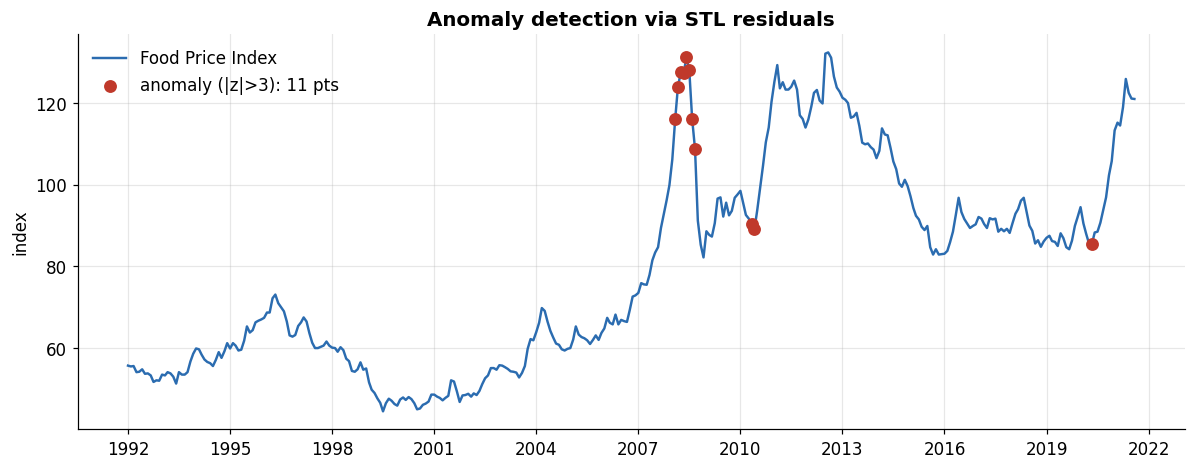

flagged months: ['2008-02', '2008-03', '2008-04', '2008-05', '2008-06', '2008-07', '2008-08', '2008-09', '2010-05', '2010-06', '2020-05']


In [6]:
from statsmodels.tsa.seasonal import STL
series = df["Food_Price_Index"]
res = STL(series, period=12, robust=True).fit()
resid = res.resid
zscore = (resid - resid.mean()) / resid.std()
anoms = series[np.abs(zscore) > 3]        # flag |z| > 3

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(series.index, series, color=PALETTE[0], label="Food Price Index")
ax.scatter(anoms.index, anoms.values, color="#c0392b", s=55, zorder=5,
           label=f"anomaly (|z|>3): {len(anoms)} pts")
ax.set_title("Anomaly detection via STL residuals")
ax.set_ylabel("index"); ax.legend(frameon=False)
ax.xaxis.set_major_locator(mdates.YearLocator(3))
plt.tight_layout(); plt.show()
print("flagged months:", [d.strftime("%Y-%m") for d in anoms.index])

The flagged months are exactly the genuine shocks — the **2008 food crisis**
cluster, **2010**, and **2020-05** (COVID). This STL-residual rule is a strong,
interpretable default; dedicated libraries (`adtk`, PyOD, or the Nixtla anomaly
tools) add seasonal-hybrid ESD, isolation forests, and probabilistic detectors
when you need them.

## 4. Intermittent & sparse demand

Some series are mostly **zeros** with occasional nonzero values — spare parts,
slow-moving inventory, rare events. Standard models (ETS, ARIMA) fail here: they
chase the zeros and forecast near zero, ignoring the demand that *does* arrive.
**Croston's method** and its relatives instead model **two things separately** —
the size of demand *when it occurs*, and the interval *between* occurrences.

Our price data isn't intermittent, so we **construct** an intermittent series to
demonstrate.

fraction of zero-demand months: 70%


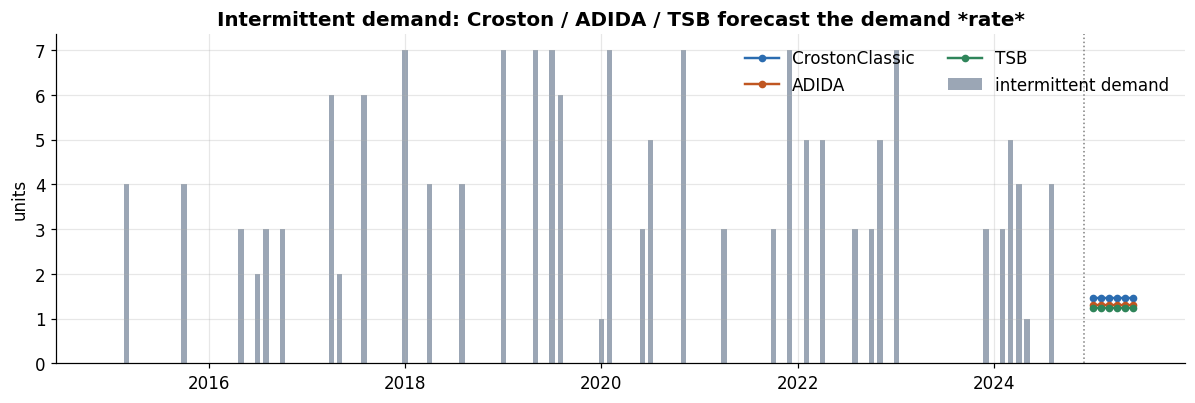

unique_id         ds  CrostonClassic  ADIDA  TSB
     part 2025-01-01            1.46   1.31 1.23


In [7]:
rng = np.random.default_rng(1); n = 120
demand = np.where(rng.random(n) < 0.3, rng.integers(1, 8, n), 0).astype(float)
idf = pd.DataFrame({"unique_id": "part",
                    "ds": pd.date_range("2015-01-01", periods=n, freq="MS"),
                    "y": demand})
print(f"fraction of zero-demand months: {(demand==0).mean():.0%}")

from statsforecast.models import CrostonClassic, ADIDA, TSB
sfi = StatsForecast(models=[CrostonClassic(), ADIDA(), TSB(alpha_d=0.1, alpha_p=0.1)],
                    freq="MS", n_jobs=1)
ifc = sfi.forecast(df=idf, h=6)

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(idf["ds"], idf["y"], width=20, color=PALETTE[5], alpha=0.7, label="intermittent demand")
future = ifc["ds"]
for m, c in zip(["CrostonClassic", "ADIDA", "TSB"], PALETTE):
    ax.plot(future, ifc[m], marker="o", ms=4, color=c, label=m)
ax.axvline(idf["ds"].iloc[-1], color="grey", ls=":", lw=1)
ax.set_title("Intermittent demand: Croston / ADIDA / TSB forecast the demand *rate*")
ax.set_ylabel("units"); ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()
print(ifc.round(2).head(1).to_string(index=False))

Each method forecasts a smooth **demand rate** (~1.2–1.5 units/period) rather than
being dragged to zero — the right target for stocking decisions. **Croston** is the
classic; **TSB** handles demand that can go obsolete (updates the probability even
in zero periods); **ADIDA** temporally aggregates to reduce intermittence. The
metric also changes: RMSE is misleading on intermittent data — practitioners use
**MASE** or scaled-error metrics instead.

## 5. Long-horizon forecasting challenges

Forecasting far ahead is qualitatively harder, for three reasons: **error
compounds** (recursive predictions feed on predictions), **uncertainty grows**
(intervals fan out), and **structure drifts** (trends bend, seasonality evolves).
We can *see* the error growth by backtesting a model over many origins and
averaging the absolute error at each horizon step.

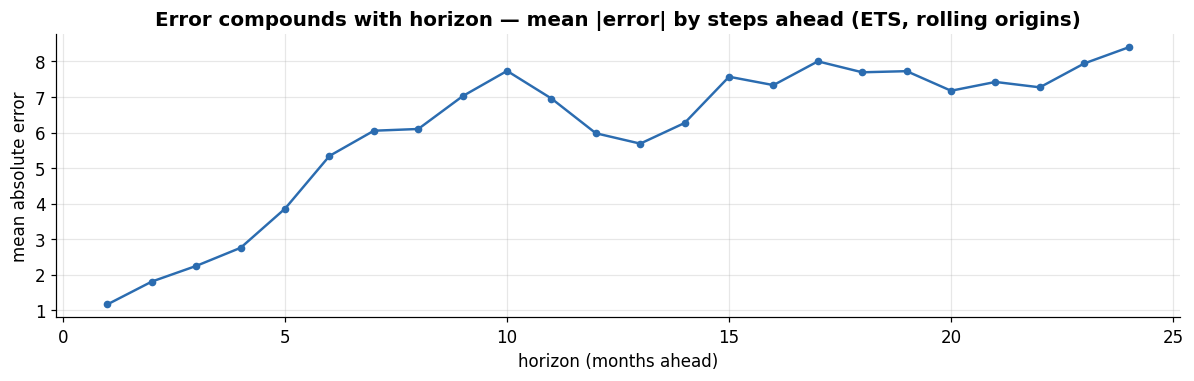

mean |error|: 1-step = 1.17  ->  24-step = 8.40 (7.2x growth)


In [8]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
y = df["Food_Price_Index"]
Hmax, origins = 24, range(len(y)-24-60, len(y)-24, 6)   # several rolling origins
errs = []
for o in origins:
    tr = y.iloc[:o]
    fc = ETSModel(tr, error="add", trend="add", damped_trend=True,
                  initialization_method="estimated").fit(disp=False).forecast(Hmax)
    actual = y.iloc[o:o+Hmax].values
    errs.append(np.abs(actual - fc.values))
mean_err = np.mean(errs, axis=0)

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(range(1, Hmax+1), mean_err, marker="o", ms=4, color=PALETTE[0])
ax.set_title("Error compounds with horizon — mean |error| by steps ahead (ETS, rolling origins)")
ax.set_xlabel("horizon (months ahead)"); ax.set_ylabel("mean absolute error")
plt.tight_layout(); plt.show()
print(f"mean |error|: 1-step = {mean_err[0]:.2f}  ->  24-step = {mean_err[-1]:.2f} "
      f"({mean_err[-1]/mean_err[0]:.1f}x growth)")

Error climbs steadily with the horizon — the fundamental tax on long-range
forecasting. Mitigations we've met: the **direct** strategy (Part 6) avoids
recursive compounding; **N-HiTS**'s multi-rate stacks (Part 10) target long
horizons specifically; and **probabilistic** outputs (Part 10) at least make the
growing uncertainty *honest*. Beyond a point, no model can manufacture signal that
isn't there — wide, well-calibrated intervals become the responsible answer.

## 6. Foundation models — zero-/few-shot forecasting

The newest and most disruptive development: **time-series foundation models** —
large networks **pretrained on billions of observations** across many domains,
then applied **zero-shot** to a brand-new series with *no local training*. They
are, in effect, the answer to the data-hunger problem that sank the deep models on
our single short series in Part 10: the model brings its *own* data, learned during
pretraining.

| Model | Origin | Core idea |
|---|---|---|
| **TimeGPT** | Nixtla | API-served transformer; zero-shot + fine-tuning, supports exogenous |
| **Chronos** | Amazon | *tokenizes* scaled values and reuses a T5 language-model backbone |
| **Moirai** | Salesforce | masked-encoder, any-frequency, any-variate universal forecaster |
| **TimesFM** | Google | decoder-only, patched inputs, trained on a huge time-series corpus |

**Capabilities:** genuinely useful **zero-shot** accuracy; strong on **short**
series (where local deep models fail); instant to apply; some accept covariates and
probabilistic outputs. **Limits:** they can miss **domain-specific** structure,
are **large** and often **API- or GPU-bound**, are **black boxes**, and — as
research is still settling — don't always beat a well-tuned classical model on a
given dataset. Still, for a short series like ours they're the most promising path
to *beating the baseline without training anything*.

The code below shows the (identical-feeling) usage for two of them. It is provided
as reference — running it needs the model **weights** (Chronos, from Hugging Face)
or an **API key** (TimeGPT), neither available in this offline notebook — so we
present it rather than execute it.

```python
# --- Chronos (Amazon): zero-shot, downloads pretrained weights from Hugging Face ---
import torch
from chronos import ChronosPipeline

pipe = ChronosPipeline.from_pretrained("amazon/chronos-t5-small",
                                       device_map="cpu", torch_dtype=torch.float32)
context = torch.tensor(train_series.values)          # your history — no fitting
forecast = pipe.predict(context, prediction_length=24)   # [num_samples, 24] draws
median = forecast.median(dim=0).values               # point forecast
lo, hi = forecast.quantile(0.1, 0), forecast.quantile(0.9, 0)   # 80% interval
```

```python
# --- TimeGPT (Nixtla): zero-shot via API (needs an API key) ---
from nixtla import NixtlaClient
client = NixtlaClient(api_key="YOUR_KEY")
fc = client.forecast(df=long_df, h=24, freq="MS", level=[80, 90])   # intervals included
```

Both follow the same pattern the whole ML/DL arc has been building toward — but
with **no training loop at all**. You hand the model your history; it returns a
forecast (and intervals) drawn from everything it learned during pretraining.

## 7. Exercises

1. **Deeper hierarchy.** Add a **grouped** dimension (e.g., split each crop into two
   synthetic regions) and compare MinT vs bottom-up as the hierarchy grows.
2. **Penalty vs count.** Run `ruptures` with `Pelt(model="rbf")` and vary `pen`;
   how does the number of detected breaks change on `Energy_Price_Index`?
3. **Anomaly threshold.** Sweep the z-threshold (2, 2.5, 3, 4) and plot how many
   anomalies each flags — the precision/recall trade-off.
4. **Intermittence.** Increase the zero-fraction to 60% and compare Croston vs a
   naive mean; which handles the sparsity better (by MASE)?
5. **Long horizon.** Repeat the error-growth curve for a **direct** multi-step model
   and overlay it — does direct grow more slowly than recursive ETS?

## 8. Key takeaways

- **Hierarchical** forecasts must be **coherent**; independent base forecasts aren't.
  **Reconciliation** (bottom-up, top-down, **MinT**) guarantees they add up — and
  MinT usually improves accuracy on large hierarchies.
- **Change-point** detection (`ruptures`) finds regime shifts — useful for
  segmentation, alerting, and deciding when to refit.
- **Anomaly** detection via **decomposition residuals** is a robust, interpretable
  default; flag points whose STL residual is a few σ from zero.
- **Intermittent demand** needs **Croston/ADIDA/TSB**, which model demand size and
  timing separately — and scale-free metrics, not RMSE.
- **Long horizons** suffer compounding error and growing uncertainty; use direct
  strategies, multi-rate architectures, and honest **intervals**.
- **Foundation models** (TimeGPT, Chronos, Moirai, TimesFM) forecast **zero-shot**
  from pretraining — the most promising route for **short** series, at the cost of
  size, opacity, and access.

### What's next — Part 12: Deployment & Capstone
The finale turns models into a **system**: persistence and reproducible pipelines,
**retraining cadence**, monitoring **drift** and forecast degradation, and serving
forecasts (batch vs. API, a Streamlit dashboard) — closing with a **capstone** that
benchmarks a statistical, an ML, and a deep model on one dataset under the Part 6
backtesting discipline.